# Interpolation entre mesures de probabilités
 By Victor Ducros & Georgii Potoshin

Le premier façons d'interpoler et en variables aleatoires. Donc on pose pour $X_0 \sim \mu_0$, $X_1 \sim \mu_1$ v.a.i. $X_t :=(1-t)X_0+tX_1$.


[T1] Si $X_0$ et $X_1$ admettent des densités $f_0$ et $f_1$, une question naturelle est de calculer la densité de $X_t$.

En passant par la méthode de la fonction muette, on prend $g$ une fonction continue bornée :
$$
\mathbb{E}(g(X_t)) = \mathbb{E}(g(h(X_0, X_1))) \quad \text{où } h(x_0, x_1) = (1 - t)x_0 + t x_1.
$$

Donc, par indépendance de $X_0$ et $X_1$ :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \int_{\mathbb{R}} g((1 - t)x_0 + t x_1) \, f(x_0) \, f(x_1) \, dx_0 \, dx_1.
$$

On effectue le changement de variable : $x = (1 - t)x_0 + t x_1$, en $x_0$ fixé.

On a :
$$
x_1 = \frac{1}{t} \left( x - (1 - t)x_0 \right),
$$
$$
dx = t \, dx_1 \quad \Rightarrow \quad dx_1 = \frac{dx}{t}.
$$

Donc :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \left( \int_{\mathbb{R}} g(x) \, f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) \frac{dx}{t}.
$$

Ce qui peut s'écrire :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} g(x) \left( \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) dx.
$$

Donc, par définition, la densité $f_t(x)$ est donnée par :
$$
f_t(x) = \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \quad \forall x \in \mathbb{R}.
$$
Cette densité est valable $\forall t \in ]0,1]$. Si $t=0$, on a $f_t=f_0$

[S1]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as npr
import scipy.stats as sps
import scipy.integrate as spi
from scipy.stats import norm, uniform

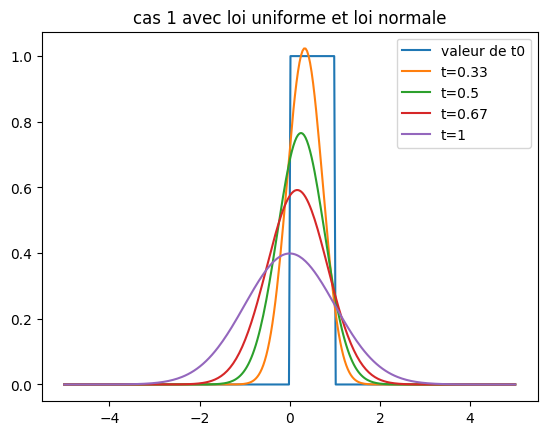

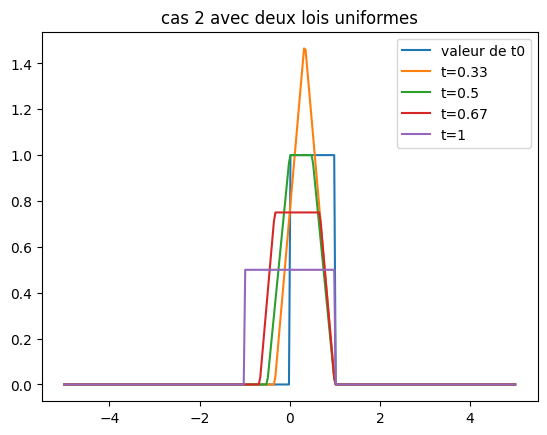

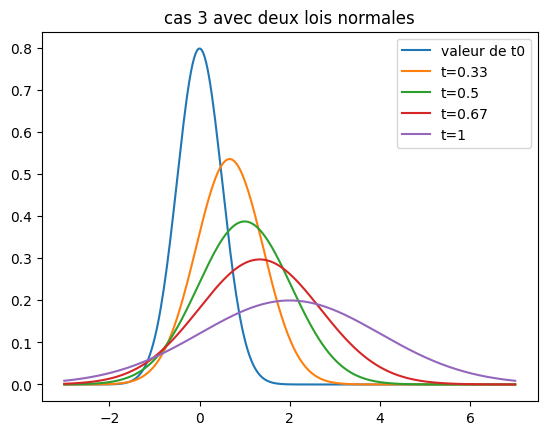

In [29]:
Lx=np.linspace(-5,5,300)
Lt=[0,1/3,1/2,2/3,1]

def va_inter(f, g, name, a=0, b=1):
    plt.plot(Lx, f.pdf(Lx),label="valeur de t"+str(0))
    for t in Lt[1:]:
        integrale, _ = spi.quad_vec(lambda x0: f.pdf(x0)*g.pdf((Lx-(1-t)*x0)/t), a, b)
        res = (1/t) * integrale
        plt.plot(Lx, res, label="t=" + str(round(t, 2)))
    plt.legend()
    plt.title(name)
    plt.show()

    
va_inter(uniform, norm, "cas 1 avec loi uniforme et loi normale")

va_inter(uniform, uniform(loc=-1, scale=2), "cas 2 avec deux lois uniformes")

Lx=np.linspace(-3,7,300)
va_inter(norm(loc=0, scale=0.5), norm(loc=2, scale=2), "cas 3 avec deux lois normales", a=-np.inf, b=+np.inf)

[T2] La classe des mesures de Dirac est close par cette opération. En effet,
si on a $f_y, f_x:M\rightarrow\mathbb R$ les v.a. de mesures image $\delta_x, \delta_y$
on a évidament $\mathbb P(tf_y+(1-t)f_x = ty+(1-t)x)=1$, comme $f_y^{-1}[y]\cap
f_x^{-1}[x]$ est de mesure 1, et donc on a pour mesure image $\delta_{tx+(1-t)y}$.

Les mesure uniform sur un interval ne sont pas clos, comme si $X$, $Y$
suivent $U([0,1])$ et qu'on regarde $Z=(X+Y)/2$, une calcule du fonction de densité
donne
\begin{align*}
    \mathbb E f(Z)&=\int f((x+y)/2)\chi_{[0,1]}(x)\chi_{[0,1]}(y)dxdy\\
    &=\int f(z)\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx 2dz\\
    &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx\right)2dz\\
    &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx\right)2dz
\end{align*}
donc la fonction de densité $d(z) = 2\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx$,
et comme on sait que $Z\in[0,1]$, on devrait avoir $d(z)=1$ sur $[0,1]$, mais
déjà $d$ n'est pas constante. Et finalement les mesures Gaussiennes sont closes
par cette opération et cela fait partie de théorie de notre cours.


[T3]

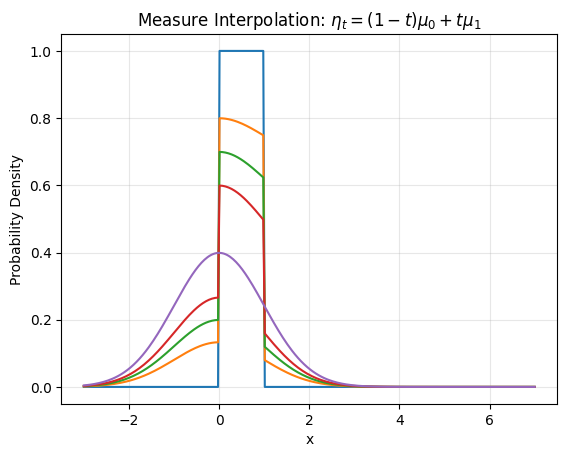

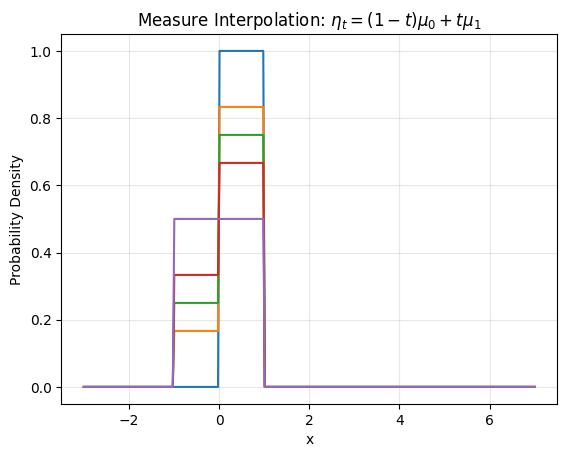

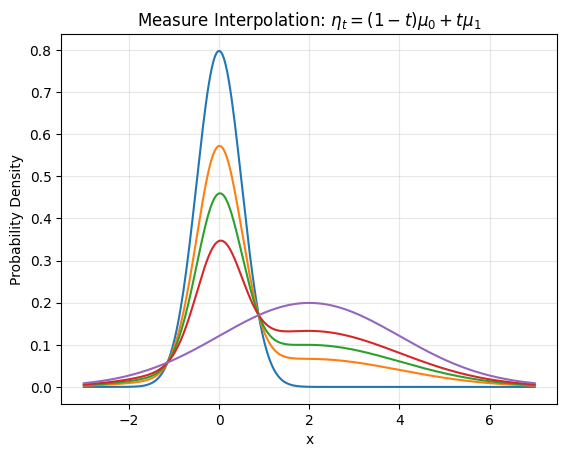

In [25]:
def meas_inter(f, g, name):
    for t in Lt:
        plt.title(r"Measure Interpolation: $\eta_t = (1-t)\mu_0 + t\mu_1$")
        plt.xlabel("x")
        plt.ylabel("Probability Density")
        plt.grid(True, alpha=0.3)
        plt.plot(Lx, (1-t)*f.pdf(Lx) + t*g.pdf(Lx), label=f"t = {t}")
    plt.show()

meas_inter(uniform, norm, "unif+norm")
meas_inter(uniform, uniform(loc=-1, scale=2), "unif+unif")
meas_inter(norm(scale=0.5), norm(loc=2, scale=2), "norm+norm")

[T6]
1. Par linéarité $\mathbb E((1-t)X_0+tX_0)= (1-t)\mathbb EX_0 + t\mathbb EX_1$. Pour $η_t = (1−t)µ_0 + tµ_1$ nous avons $\mathbb EX_t=\int xd(t\mu_1+(1-t)\mu_0)=t\intf\mu_1+(1-t)\intd\mu_0$, car les mesures forme l'éspace dual des fonctions continues à support compact, avec l'action – prendre l'integrale. Et finalement pour $Z_t = (1−t)F^{−1}_0(U)+tF^{−1}_1(U)$ on passe par le même argument que dans le premièr cas, car $F^{-1}_i(U)$ suis le même loi que $X_i$.
2. Suppoosons que $\mu_0=\mu_1$. Qu'est peut on dit d'interpolations? Pour 